In [1]:
# 檔案: database.py
# 1. 從你剛剛貼的檔案 (postgres_client.py) 匯入這個 Class
from database.postgres_client import PostgresEasyClient 

import os
from dotenv import load_dotenv

# load_dotenv()

# 設定檔
DB_CONFIG = {
    "user": os.getenv("DB_USER", "ai_user"),
    "password": os.getenv("DB_PASSWORD", "ai_password"),
    "host": os.getenv("DB_HOST", "127.0.0.1"),
    "port": os.getenv("DB_PORT", "5433"),
    "dbname": os.getenv("DB_NAME", "stock_db")
}

# 2. 這就是那把萬能鑰匙
def get_db_client():
    return PostgresEasyClient(**DB_CONFIG)

In [4]:
pwd

'c:\\Users\\Qoo\\Desktop\\my_workspace\\reason-stock-agent'

In [2]:
from data_collector import DataCollector

collector = DataCollector()
collector.run_backfill()



🚀 [資料模組啟動] 2026-03-13 14:34:59
   目標：補齊過去 1 年 (365天) 的缺漏資料
---------------------------------------------------
   📈 [1/5] 台股回補 (TWStock)...

🚀 [TW_Stock] 啟動中...
🚀 [台股] 模式: backfill, 檢查區間: 2025-03-13 -> 2026-03-12
🕷️ [台股] 抓取: 2026-03-12 ...
   ✅ 寫入: 2102 筆
🕷️ [台股] 抓取: 2026-03-11 ...
   ✅ 寫入: 2102 筆
🕷️ [台股] 抓取: 2026-03-10 ...
   ✅ 寫入: 2102 筆
🕷️ [台股] 抓取: 2026-03-09 ...
   ✅ 寫入: 2102 筆
🕷️ [台股] 抓取: 2026-03-06 ...
   ✅ 寫入: 2102 筆
🕷️ [台股] 抓取: 2026-03-05 ...
   ✅ 寫入: 2102 筆
🕷️ [台股] 抓取: 2026-03-04 ...
   ✅ 寫入: 2102 筆
🕷️ [台股] 抓取: 2026-03-03 ...
   ✅ 寫入: 2102 筆
🕷️ [台股] 抓取: 2026-03-02 ...
   ✅ 寫入: 2102 筆
🕷️ [台股] 抓取: 2026-02-27 ...
   ⚠️ 異常：僅有上櫃資料，跳過。
🕷️ [台股] 抓取: 2026-02-26 ...
   ✅ 寫入: 2102 筆
🕷️ [台股] 抓取: 2026-02-25 ...
   ✅ 寫入: 2102 筆
🕷️ [台股] 抓取: 2026-02-24 ...
   ✅ 寫入: 2102 筆
🕷️ [台股] 抓取: 2026-02-23 ...
   ✅ 寫入: 2102 筆
🕷️ [台股] 抓取: 2026-02-20 ...
   ⚠️ 異常：僅有上櫃資料，跳過。
🕷️ [台股] 抓取: 2026-02-19 ...
   ⚠️ 異常：僅有上櫃資料，跳過。
🕷️ [台股] 抓取: 2026-02-18 ...
   ⚠️ 異常：僅有上櫃資料，跳過。
🕷️ [台股] 抓取: 2026-02-17 ...
   ⚠️ 異常：僅有上

In [19]:
from crawlers.price import TWStockCrawler, USStockCrawler
from crawlers.news import AnueCrawler, GoogleNewsCrawler, PTTCrawler
from datetime import datetime



# USStockCrawler().run_safe(mode="backfill", years_back=1)
AnueCrawler().run_safe(days_back=365, mode="backfill")



🚀 [Anue_News] 啟動中...
      ✅ [Anue] 資料完美連續 (涵蓋 2026-03-13 ~ 2024-04-08)，無需執行。
✅ [Anue_News] 完成


In [3]:
import os
from database import get_db_client
import pandas as pd



print("🚀 開始全資料庫備份...")

with get_db_client() as db:
    # 1. 查詢資料庫有哪些表格 (PostgreSQL 語法)
    sql_get_tables = "SELECT tablename FROM pg_tables WHERE schemaname = 'public';"
    df_tables = pd.read_sql(sql_get_tables, db.engine)
    tables = df_tables['tablename'].tolist()
tables

🚀 開始全資料庫備份...


['system_execution_logs',
 'us_daily_prices',
 'us_update_logs',
 'tw_daily_prices',
 'tw_crawler_logs',
 'market_intelligence']

In [6]:

with get_db_client() as db:
    df = db.fetch('market_intelligence')
df = df.sort_values(by='publish_date')
df[:2]

,id,url_hash,publish_date,title,url,source,content,summary,sentiment_score,process_status,created_at
18200,18883,2d42ea2644d3da405b1eee273688257b69bc6e4329a2ac...,2024-04-08 18:15:24,營收速報 - 泰茂(2230)3月營收年增大幅成長121.23%,https://news.cnyes.com/news/id/5516320,Anue,None,None,None,PENDING,2026-02-03 00:59:54.479535
18199,18882,fa31837718fe47a8b38c6250a322e8246633e8474705e0...,2024-04-08 18:15:27,營收速報 - 三商電(2427)3月營收年增大幅成長293.26%,https://news.cnyes.com/news/id/5516321,Anue,None,None,None,PENDING,2026-02-03 00:59:54.479535


In [ ]:
  df_filtered = db.fetch(
        table="test_products",
        cols=["publish_date"],           # 指定回傳的欄位
        where={"name": "Apple"}        # 指定篩選條件
    )

In [ ]:
import pandas as pd
# 假設你從同個專案環境中引入
from database.postgres_client import PostgresEasyClient

# 設定資料庫連線參數 (需替換為你實際的設定)
db_config = {
    "user": "ai_user",
    "password": "ai_password",
    "host": "127.0.0.1",
    "port": "5433",
    "dbname": "stock_db"
}

# 1. 使用 Context Manager 初始化連線 (__enter__ 與 __exit__)
# 這樣在離開 with 區塊時，程式會自動呼叫 db.engine.dispose() 關閉連線
with PostgresEasyClient(**db_config) as db:
    print("🚀 資料庫連線成功！")

    # ==========================================
    # 2. execute_raw() 範例
    # 用途：執行原始的 SQL 語法，例如建立表格、刪除表格或建立 Index。
    # ==========================================
    print("\n[執行 execute_raw]")
    create_table_sql = """
        CREATE TABLE IF NOT EXISTS test_products (
            id INT PRIMARY KEY,
            name VARCHAR(50),
            price NUMERIC,
            features vector(3) -- pgvector 向量欄位
        );
    """
    db.execute_raw(create_table_sql)
    print("✅ 成功建立 (或確認已存在) test_products 表格")


    # ==========================================
    # 3. upsert_from_df() 範例
    # 用途：將 Pandas DataFrame 的資料寫入資料庫。
    # 特性：若 `on` 指定的 Primary Key 已存在，則自動「更新」；若不存在則「新增」。
    # ==========================================
    print("\n[執行 upsert_from_df]")
    # 準備一組測試用的 DataFrame
    data = {
        "id": [1, 2, 3],
        "name": ["Apple", "Banana", "Orange"],
        "price": [30.5, 15.0, 20.0],
        # 向量資料寫入前通常以字串形式的陣列表示
        "features": ["[1.0, 0.5, 0.1]", "[0.2, 1.0, 0.3]", "[0.8, 0.8, 0.8]"] 
    }
    df_to_insert = pd.DataFrame(data)
    
    # on=["id"] 代表以 id 作為判斷是否重複的依據
    rows_affected = db.upsert_from_df(table="test_products", df=df_to_insert, on=["id"])
    print(f"✅ 成功 Upsert 寫入/更新了 {rows_affected} 筆資料")


    # ==========================================
    # 4. fetch() 範例
    # 用途：查詢資料庫內容，並直接回傳成為 Pandas DataFrame
    # ==========================================
    print("\n[執行 fetch]")
    
    # 4-a. 查詢全部資料
    df_all = db.fetch(table="test_products")
    print("🔍 查詢全部資料:")
    print(df_all)

    # 4-b. 帶條件與指定欄位的查詢 (相當於 SELECT id, name FROM test_products WHERE name = 'Apple')
    df_filtered = db.fetch(
        table="test_products",
        cols=["id", "name"],           # 指定回傳的欄位
        where={"name": "Apple"}        # 指定篩選條件
    )
    print("\n🔍 條件查詢 (name='Apple'):")
    print(df_filtered)


    # ==========================================
    # 5. search_vector() 範例
    # 用途：透過 pgvector 進行相似度比對，找出與 query_vector 距離最接近的資料
    # ==========================================
    print("\n[執行 search_vector]")
    
    # 假設我們想找一個特徵最接近 [0.9, 0.6, 0.2] 的產品
    query_vec = [0.9, 0.6, 0.2]
    
    df_search = db.search_vector(
        table="test_products",
        vector_col="features",    # 表格中的向量欄位名稱
        query_vector=query_vec,   # 要比對的目標向量
        limit=2                   # 只抓取最相近的前 2 筆
    )
    print("🔍 向量相似度搜尋結果 (依照 distance 距離由小到大排序):")
    print(df_search)


In [14]:
df = df.sort_values(by='date')
df = df[df['ticker']=='AAPL']

In [ ]:
import requests

# 取得 NVIDIA 最新的 8-K 文件清單
url = "https://data.sec.gov/submissions/CIK0001045810.json"
headers = {"User-Agent": "yourname yourmail@gmail.com"}  # SEC 要求填這個

response = requests.get(url, headers=headers)
data = response.json()
data

讀取：NVIDIA_report_20260313_1635.json

  📋 NVIDIA 財報分析報告
  📅 文件日期：2026-03-06
  🌐 資料來源：SEC EDGAR
  🕐 分析時間：2026-03-13 16:35

📊 財務數字
  （無資料）

🇹🇼 台灣供應鏈相關提及
  • VARIABLE COMPENSATION PLAN – FISCAL YEAR 2027 ... The compensation philosophy of NVIDIA Corporation (the “ ... ”) is to attract, motivate, retain and reward its management through a combination of base salary and performance based compensation.  Certain Senior Officers, as defined below (collectivel
  • For purposes of the Plan, only the Company’s chief executive officer, chief financial officer and other named executive officers shall be considered “Senior Officers.”  The Committee shall determine the persons to be specified as Senior Officers for purposes of this Plan and the Senior Officers who 
  • Determination of Fiscal Year 2027 Payments ... Each Participant is eligible to earn compensation under the Plan at a specified base amount (the “ ... ”) if the Company achieves its Performance Goals at a specified base level. A Particip

In [1]:
pwd

'c:\\Users\\Qoo\\Desktop\\my_workspace\\reason-stock-agent'

📊 [繪圖] 正在查詢 2330 (tw_daily_prices) 過去 180 天的 close 數據...


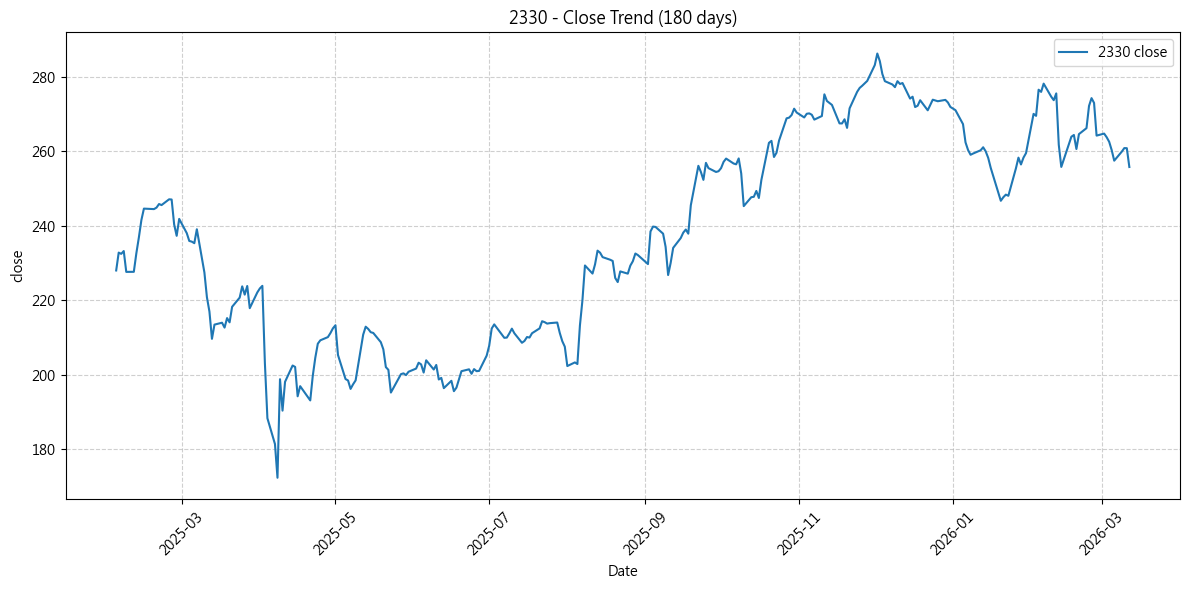